#1.データ読み込み

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [32]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/NTCIR-19/input_pairs.csv')
df.head()

,id,ペア番号,ペア,痛み,しびれ,振る舞い,トリアージ,質問,回答,ペアのベクトル,cos_sim_ひし形_全通り_頭痛_1,cos_sim_ひし形_全通り_頭痛_2,cos_sim_ひし形_全通り_頭痛_3,cos_sim_ひし形_直接,採用ペア_ひし形_全通り_頭痛_1,採用ペア_ひし形_全通り_頭痛_2,採用ペア_ひし形_全通り_頭痛_3,採用ペア_ひし形_直接
0,1,0,救急ですか、火事ですか。 救急です。夫の様子がおかしいです。,0,0,0,1,救急ですか、火事ですか。,救急です。夫の様子がおかしいです。,"[-0.07553009688854218, 0.6543946266174316, -0....",0.333049,0.114088,0.417469,0.579390,False,False,False,True
1,1,1,どうしましたか。 さっきテレビを見ていたら、急に頭を押さえて、ものすごく痛いって言い出しまし...,0,0,0,1,どうしましたか。,さっきテレビを見ていたら、急に頭を押さえて、ものすごく痛いって言い出しました。頭痛です。,"[-0.5534268617630005, 0.2958027720451355, 0.28...",0.371689,0.142192,0.481872,0.500633,True,False,False,False
2,1,2,その頭の痛みは、急に強く出たんですね。 はい、突然です。今までにないくらい痛いと言っています。,0,0,0,1,その頭の痛みは、急に強く出たんですね。,はい、突然です。今までにないくらい痛いと言っています。,"[-0.4428359568119049, 0.2741571366786957, 0.06...",0.343067,0.164993,0.551439,0.481516,False,True,True,False
3,1,3,手足のしびれや、片側が動かしにくい感じはありますか。 あります。右手がうまく動かないみたいで...,0,0,0,1,手足のしびれや、片側が動かしにくい感じはありますか。,あります。右手がうまく動かないみたいで、しびれるとも言っています。,"[-0.2704547345638275, -0.16498802602291107, 0....",0.372393,0.195094,0.343052,0.533501,True,True,False,False
4,1,4,いつもと違って、受け答えがおかしいとか、様子が変だということはありますか。 はい、あります。...,0,0,0,1,いつもと違って、受け答えがおかしいとか、様子が変だということはありますか。,はい、あります。呼びかけても返事が遅いですし、言葉も少し変で、ぼんやりしています。,"[-0.264884889125824, -0.10918011516332626, 0.2...",0.266853,0.180636,0.381274,0.439162,False,True,False,False


# 2.直接BERT

## 2.1.学習

In [ ]:
# !pip install transformers fugashi unidic-lite torch pandas japanize-matplotlib

In [56]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import BertJapaneseTokenizer, BertForSequenceClassification
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Filter the DataFrame based on '採用ペア_ひし形_直接' being True
filtered_df_direct = df[df['採用ペア_ひし形_直接'] == True]

# Group by 'id' and concatenate the 'ペア' column
processed_data_direct = filtered_df_direct.groupby('id').agg(
    input_text=('ペア', lambda x: ' '.join(x)),
    label=('トリアージ', 'first') # Target label for 直接BERT is 'トリアージ'
).reset_index()

# Encode the 'トリアージ' column to numerical labels
label_encoder_direct = LabelEncoder()
processed_data_direct['encoded_label'] = label_encoder_direct.fit_transform(processed_data_direct['label'])

# Check unique labels for num_labels
unique_labels_direct = processed_data_direct['encoded_label'].nunique()
print(f"Number of unique 'トリアージ' labels: {unique_labels_direct}")
if unique_labels_direct <= 1:
    print("Warning: Only one or no unique 'トリアージ' label found. Multi-class classification cannot be performed.")
    print("Please adjust your data filtering or input CSV to include multiple 'トリアージ' categories for multi-class classification.")

# Split the data into training and testing sets
X_direct = processed_data_direct['input_text']
y_direct = processed_data_direct['encoded_label']

# Use a consistent random state for reproducibility
X_train_direct, X_test_direct, y_train_direct, y_test_direct = train_test_split(
    X_direct, y_direct, test_size=1/3, random_state=42, stratify=y_direct if unique_labels_direct > 1 else None
)

print(f"Training set size for 直接BERT: {len(X_train_direct)}")
print(f"Test set size for 直接BERT: {len(X_test_direct)}")

# Map original labels to encoded labels
label_mapping_direct = dict(zip(label_encoder_direct.classes_, label_encoder_direct.transform(label_encoder_direct.classes_)))
print(f"Label mapping for 直接BERT: {label_mapping_direct}")

# Load tokenizer
tokenizer_direct = BertJapaneseTokenizer.from_pretrained('cl-tohoku/bert-base-japanese-whole-word-masking')

# Tokenize training data
encoded_train_data_direct = tokenizer_direct(
    X_train_direct.tolist(),
    padding='max_length',
    truncation=True,
    max_length=max_len, # Reusing max_len from previous context
    return_tensors='pt'
)

# Create TensorDataset for training
train_dataset_direct = TensorDataset(
    encoded_train_data_direct['input_ids'],
    encoded_train_data_direct['attention_mask'],
    torch.tensor(y_train_direct.tolist())
)

# Tokenize test data
encoded_test_data_direct = tokenizer_direct(
    X_test_direct.tolist(),
    padding='max_length',
    truncation=True,
    max_length=max_len, # Reusing max_len from previous context
    return_tensors='pt'
)

# Create TensorDataset for test
test_dataset_direct = TensorDataset(
    encoded_test_data_direct['input_ids'],
    encoded_test_data_direct['attention_mask'],
    torch.tensor(y_test_direct.tolist())
)

# Create DataLoaders
train_dataloader_direct = DataLoader(train_dataset_direct, batch_size=4, shuffle=True)
test_dataloader_direct = DataLoader(test_dataset_direct, batch_size=4, shuffle=False)

# Load model
device_direct = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_direct = BertForSequenceClassification.from_pretrained(
    'cl-tohoku/bert-base-japanese-whole-word-masking',
    num_labels=unique_labels_direct,
    attn_implementation='eager'
)
model_direct.to(device_direct)
optimizer_direct = AdamW(model_direct.parameters(), lr=2e-5)

# Training loop
epochs = 3 # Reusing epochs from previous context
print("\n--- Training for 直接BERT ---")
for epoch in range(epochs):
    train_loss = train_shibire(model_direct, train_dataloader_direct, optimizer_direct, device_direct)
    test_loss, accuracy, f1, precision, recall, _, _ = evaluate_shibire(model_direct, test_dataloader_direct, device_direct, label_encoder_direct)
    print(f"Epoch {epoch+1}: Train Loss {train_loss:.4f}, Test Loss {test_loss:.4f}, Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

Number of unique 'トリアージ' labels: 3
Training set size for 直接BERT: 4
Test set size for 直接BERT: 3
Label mapping for 直接BERT: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cl-tohoku/bert-base-japanese-whole-word-masking
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the che


--- Training for 直接BERT ---
Epoch 1: Train Loss 1.0950, Test Loss 1.2103, Accuracy: 0.3333, F1-Score: 0.1667, Precision: 0.1111, Recall: 0.3333
Epoch 2: Train Loss 0.9634, Test Loss 1.2856, Accuracy: 0.3333, F1-Score: 0.1667, Precision: 0.1111, Recall: 0.3333
Epoch 3: Train Loss 0.8587, Test Loss 1.3976, Accuracy: 0.0000, F1-Score: 0.0000, Precision: 0.0000, Recall: 0.0000


##2.2.評価とAttention

In [57]:
import numpy as np

model_direct.eval()
predictions_direct = []
true_labels_direct = []

with torch.no_grad():
    for batch in test_dataloader_direct:
        b_input_ids, b_input_mask, b_labels = [b.to(device_direct) for b in batch]

        outputs = model_direct(b_input_ids, attention_mask=b_input_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).flatten()

        predictions_direct.extend(preds.cpu().numpy())
        true_labels_direct.extend(b_labels.cpu().numpy())

# デコードされた予測ラベルと真のラベル
decoded_predictions_direct = label_encoder_direct.inverse_transform(predictions_direct)
decoded_true_labels_direct = label_encoder_direct.inverse_transform(true_labels_direct)

# テストデータと予測結果を結合して表示
results_df_direct = pd.DataFrame({
    'Input Text': X_test_direct.values,
    'True Label (Encoded)': y_test_direct.values,
    'True Label': decoded_true_labels_direct,
    'Predicted Label (Encoded)': predictions_direct,
    'Predicted Label': decoded_predictions_direct
})

print("\n--- テストデータに対する予測結果 (直接BERT) ---")
display(results_df_direct)


--- テストデータに対する予測結果 (直接BERT) ---


,Input Text,True Label (Encoded),True Label,Predicted Label (Encoded),Predicted Label
0,どうしましたか。 さっき外で会った時は普通だったんですが、少しして見に行ったら頭を押さえてし...,0,0,1,1
1,救急ですか、火事ですか。 救急です。夫の様子がおかしいです。,1,1,2,2
2,何がありましたか。 数時間前から頭が痛いと言っていて、今は裏の休憩スペースで座っています。冷...,2,2,1,1


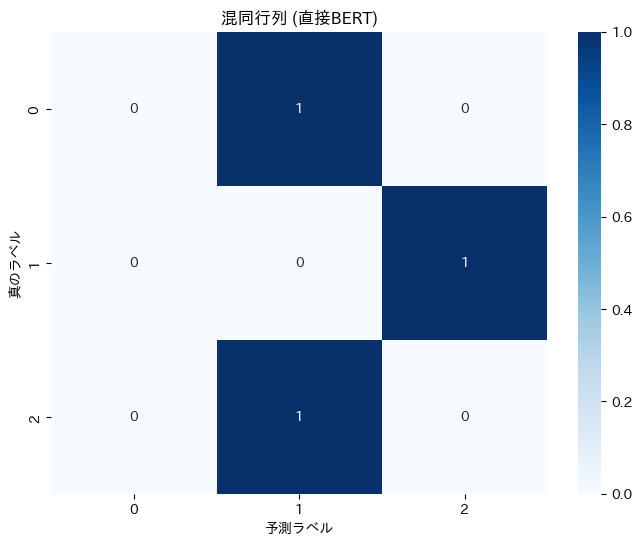

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt
import japanize_matplotlib # Ensure Japanese font support

# 混同行列を計算
cm_direct = confusion_matrix(true_labels_direct, predictions_direct)

# クラス名を取得（エンコード前のラベル）
class_names_direct = label_encoder_direct.classes_

# 混同行列を可視化
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_direct,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names_direct,
    yticklabels=class_names_direct
)
plt.xlabel('予測ラベル')
plt.ylabel('真のラベル')
plt.title('混同行列 (直接BERT)')
plt.show()

In [59]:
from IPython.display import display, HTML
import torch

# 1. モデルのAttention出力を有効化
model_direct.config.output_attentions = True

# 2. 推論実行 (Using the same example text as before for consistency)
text_direct = "どうしましたか。昼ごろから頭が痛いと言っていたんですが、さっき様子を見に行ったら、片側がしびれるみたいで、いつもと全然違うんです。頭痛は突然ひどくなったわけではないですか。はい、急にではないです。何時間か前から続いていて、だんだん悪くなったようです。しびれや麻痺はどこに出ていますか。右の手足がしびれると言っています。歩こうとしても片側に寄ってしまいます。いつもと違う受け答えや行動はありますか。あります。部屋の鍵をどこに置いたか急にわからなくなって、私の名前もすぐ出てきませんでした。" # You can change this input text
inputs_direct = tokenizer_direct(text_direct, return_tensors='pt', add_special_tokens=True).to(device_direct)

with torch.no_grad():
    outputs_direct = model_direct(**inputs_direct)

# 3. 最後の層のAttentionを取得
# 形状: [num_heads, sequence_length, sequence_length]
attn_weights_direct = outputs_direct.attentions[-1][0]

# 全ヘッドの平均をとる
avg_attn_direct = attn_weights_direct.mean(dim=0);

# [CLS]トークン（文頭）が他のトークンに向けたAttentionを取得
# [CLS]のインデックス0の行を取り出します
cls_attention_direct = avg_attn_direct[0];

# 4. トークンの取得
tokens_direct = tokenizer_direct.convert_ids_to_tokens(inputs_direct['input_ids'][0])

# 5. HTMLで可視化
html_output_direct = ""
for token, weight in zip(tokens_direct, cls_attention_direct):
    # 重みを0~1に正規化（表示を見やすくするために係数をかけて調整）
    # 値が小さい場合は少し底上げして見えやすくします
    opacity = min(weight.item() * 10, 1.0)

    # 背景色（黄色）の不透明度(opacity)をAttentionスコアに連動させる
    html_output_direct += f'<span style="background-color: rgba(255, 255, 0, {opacity}); padding: 2px; border-radius: 3px;">{token}</span> '

print("\n--- Attention Visualization (直接BERT) ---")
display(HTML(html_output_direct))


--- Attention Visualization (直接BERT) ---


# 3.全通りBERT

##3.1.ひし形_1専用BERT

###3.1.1.学習

In [ ]:
# !pip install transformers fugashi unidic-lite torch pandas japanize-matplotlib

In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import BertJapaneseTokenizer, BertForSequenceClassification
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Filter the DataFrame based on '採用ペア_ひし形_全通り_頭痛_1' being True
filtered_df = df[df['採用ペア_ひし形_全通り_頭痛_1'] == True]

# Group by 'id' and concatenate the 'ペア' column
# Also, get the '痛み' value for each id (assuming '痛み' is constant for a given id)
processed_data = filtered_df.groupby('id').agg(
    input_text=('ペア', lambda x: ' '.join(x)),
    label=('痛み', 'first') # Assuming '痛み' is constant per id
).reset_index()


# Encode the '痛み' (pain) column to numerical labels
label_encoder = LabelEncoder()
processed_data['encoded_label'] = label_encoder.fit_transform(processed_data['label'])

# Split the data into training and testing sets
X = processed_data['input_text']
y = processed_data['encoded_label']

# Use a consistent random state for reproducibility
# Stratify only if there are multiple unique labels
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=42, stratify=y if unique_labels > 1 else None)


# Map original labels to encoded labels
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))


In [42]:
# Load tokenizer
tokenizer = BertJapaneseTokenizer.from_pretrained('cl-tohoku/bert-base-japanese-whole-word-masking')

# Tokenize training data
encoded_train_data = tokenizer(
    X_train.tolist(),
    padding='max_length',
    truncation=True,
    max_length=max_len, # Use max_len from kernel state (128)
    return_tensors='pt'
)

# Create TensorDataset for training
train_dataset = TensorDataset(
    encoded_train_data['input_ids'],
    encoded_train_data['attention_mask'],
    torch.tensor(y_train.tolist()) # Convert Series to list then to tensor
)

# Tokenize test data
encoded_test_data = tokenizer(
    X_test.tolist(),
    padding='max_length',
    truncation=True,
    max_length=max_len, # Use max_len from kernel state (128)
    return_tensors='pt'
)

# Create TensorDataset for test
test_dataset = TensorDataset(
    encoded_test_data['input_ids'],
    encoded_test_data['attention_mask'],
    torch.tensor(y_test.tolist()) # Convert Series to list then to tensor
)

# Create DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=False) # Changed from valid_dataloader to test_dataloader

# Load model
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = BertForSequenceClassification.from_pretrained(
    'cl-tohoku/bert-base-japanese-whole-word-masking',
    num_labels=unique_labels, # Use unique_labels from kernel state (3)
    attn_implementation='eager'
)
model.to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)

def train(model, dataloader):
    model.train()
    total_loss = 0
    for batch in dataloader:
        b_input_ids, b_input_mask, b_labels = [b.to(device) for b in batch]
        optimizer.zero_grad()
        outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate(model, dataloader): # Renamed from validation to evaluate
    model.eval()
    val_loss = 0
    # Add metrics for multi-class classification
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in dataloader:
            b_input_ids, b_input_mask, b_labels = [b.to(device) for b in batch]
            outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)
            val_loss += outputs.loss.item()
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1).flatten()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(b_labels.cpu().numpy())

    # Calculate and return metrics
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted') # Use 'weighted' for multi-class
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')

    return val_loss / len(dataloader), accuracy, f1, precision, recall

# Training loop
epochs = 3 # Using epochs from kernel state
for epoch in range(epochs):
    train_loss = train(model, train_dataloader)
    test_loss, accuracy, f1, precision, recall = evaluate(model, test_dataloader) # Call evaluate function
    print(f"Epoch {epoch+1}: Train Loss {train_loss:.4f}, Test Loss {test_loss:.4f}, Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cl-tohoku/bert-base-japanese-whole-word-masking
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the che

Epoch 1: Train Loss 1.1343, Test Loss 1.1380, Accuracy: 0.3333, F1-Score: 0.1667, Precision: 0.1111, Recall: 0.3333


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 2: Train Loss 1.0128, Test Loss 1.1504, Accuracy: 0.3333, F1-Score: 0.1667, Precision: 0.1111, Recall: 0.3333
Epoch 3: Train Loss 0.9227, Test Loss 1.1853, Accuracy: 0.3333, F1-Score: 0.1667, Precision: 0.1111, Recall: 0.3333


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


###3.1.1.評価とAttention

In [43]:
import numpy as np

model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for batch in test_dataloader:
        b_input_ids, b_input_mask, b_labels = [b.to(device) for b in batch]

        outputs = model(b_input_ids, attention_mask=b_input_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).flatten()

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(b_labels.cpu().numpy())

# デコードされた予測ラベルと真のラベル
decoded_predictions = label_encoder.inverse_transform(predictions)
decoded_true_labels = label_encoder.inverse_transform(true_labels)

# テストデータと予測結果を結合して表示
results_df = pd.DataFrame({
    'Input Text': X_test.values,
    'True Label (Encoded)': y_test.values,
    'True Label': decoded_true_labels,
    'Predicted Label (Encoded)': predictions,
    'Predicted Label': decoded_predictions
})

print("テストデータに対する予測結果:")
display(results_df)

テストデータに対する予測結果:


,Input Text,True Label (Encoded),True Label,Predicted Label (Encoded),Predicted Label
0,救急ですか、火事ですか。 救急です。入所者さんが急な頭痛を訴えています。 その頭痛は急に起き...,0,0,0,0
1,いつもと違って混乱しているとか、変なことを言う様子はありますか。 ありません。受け答えはしっ...,1,1,0,0
2,救急ですか、火事ですか。 救急です。近所の方が頭が痛いと言って、部屋の前でうずくまっています...,2,2,0,0


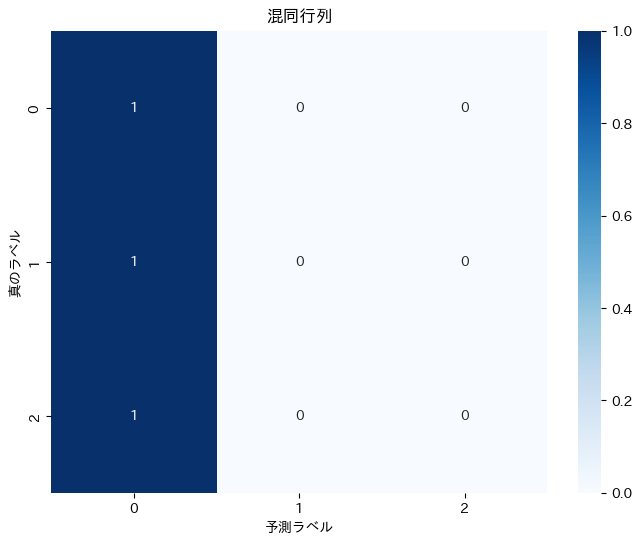

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 混同行列を計算
cm = confusion_matrix(true_labels, predictions)

# クラス名を取得（エンコード前のラベル）
class_names = label_encoder.classes_

# 混同行列を可視化
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('予測ラベル')
plt.ylabel('真のラベル')
plt.title('混同行列')
plt.show()

In [46]:
from IPython.display import display, HTML
import torch

# 1. モデルのAttention出力を有効化
model.config.output_attentions = True

# 2. 推論実行
text = "どうしましたか。昼ごろから頭が痛いと言っていたんですが、さっき様子を見に行ったら、片側がしびれるみたいで、いつもと全然違うんです。頭痛は突然ひどくなったわけではないですか。はい、急にではないです。何時間か前から続いていて、だんだん悪くなったようです。しびれや麻痺はどこに出ていますか。右の手足がしびれると言っています。歩こうとしても片側に寄ってしまいます。いつもと違う受け答えや行動はありますか。あります。部屋の鍵をどこに置いたか急にわからなくなって、私の名前もすぐ出てきませんでした。" # You can change this input text
inputs = tokenizer(text, return_tensors='pt', add_special_tokens=True).to(device)

with torch.no_grad():
    outputs = model(**inputs)

# 3. 最後の層のAttentionを取得
# 形状: [num_heads, sequence_length, sequence_length]
attn_weights = outputs.attentions[-1][0]

# 全ヘッドの平均をとる
avg_attn = attn_weights.mean(dim=0)

# [CLS]トークン（文頭）が他のトークンに向けたAttentionを取得
# [CLS]のインデックス0の行を取り出します
cls_attention = avg_attn[0]

# 4. トークンの取得
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

# 5. HTMLで可視化
html_output = ""
for token, weight in zip(tokens, cls_attention):
    # 重みを0~1に正規化（表示を見やすくするために係数をかけて調整）
    # 値が小さい場合は少し底上げして見えやすくします
    opacity = min(weight.item() * 10, 1.0)

    # 背景色（黄色）の不透明度(opacity)をAttentionスコアに連動させる
    html_output += f'<span style="background-color: rgba(255, 255, 0, {opacity}); padding: 2px; border-radius: 3px;">{token}</span> '

display(HTML(html_output))

##3.2.ひし形_2専用BERT

###3.2.1.学習

In [ ]:
# !pip install transformers fugashi unidic-lite torch pandas japanize-matplotlib

In [47]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import BertJapaneseTokenizer, BertForSequenceClassification
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Filter the DataFrame based on '採用ペア_ひし形_全通り_頭痛_2' being True
filtered_df_shibire = df[df['採用ペア_ひし形_全通り_頭痛_2'] == True]

# Group by 'id' and concatenate the 'ペア' column
processed_data_shibire = filtered_df_shibire.groupby('id').agg(
    input_text=('ペア', lambda x: ' '.join(x)),
    label=('しびれ', 'first') # Target label for ひし形_2 is 'しびれ'
).reset_index()

# Encode the 'しびれ' column to numerical labels
label_encoder_shibire = LabelEncoder()
processed_data_shibire['encoded_label'] = label_encoder_shibire.fit_transform(processed_data_shibire['label'])

# Check unique labels for num_labels
unique_labels_shibire = processed_data_shibire['encoded_label'].nunique()
print(f"Number of unique 'しびれ' labels: {unique_labels_shibire}")
if unique_labels_shibire <= 1:
    print("Warning: Only one or no unique 'しびれ' label found. Multi-class classification cannot be performed.")
    print("Please adjust your data filtering or input CSV to include multiple 'しびれ' categories for multi-class classification.")

# Split the data into training and testing sets
X_shibire = processed_data_shibire['input_text']
y_shibire = processed_data_shibire['encoded_label']

# Use a consistent random state for reproducibility
X_train_shibire, X_test_shibire, y_train_shibire, y_test_shibire = train_test_split(
    X_shibire, y_shibire, test_size=1/3, random_state=42, stratify=y_shibire if unique_labels_shibire > 1 else None
)

print(f"Training set size for しびれ: {len(X_train_shibire)}")
print(f"Test set size for しびれ: {len(X_test_shibire)}")

# Map original labels to encoded labels
label_mapping_shibire = dict(zip(label_encoder_shibire.classes_, label_encoder_shibire.transform(label_encoder_shibire.classes_)))
print(f"Label mapping for しびれ: {label_mapping_shibire}")

# Load tokenizer
tokenizer_shibire = BertJapaneseTokenizer.from_pretrained('cl-tohoku/bert-base-japanese-whole-word-masking')

# Tokenize training data
encoded_train_data_shibire = tokenizer_shibire(
    X_train_shibire.tolist(),
    padding='max_length',
    truncation=True,
    max_length=max_len, # Reusing max_len from previous context
    return_tensors='pt'
)

# Create TensorDataset for training
train_dataset_shibire = TensorDataset(
    encoded_train_data_shibire['input_ids'],
    encoded_train_data_shibire['attention_mask'],
    torch.tensor(y_train_shibire.tolist())
)

# Tokenize test data
encoded_test_data_shibire = tokenizer_shibire(
    X_test_shibire.tolist(),
    padding='max_length',
    truncation=True,
    max_length=max_len, # Reusing max_len from previous context
    return_tensors='pt'
)

# Create TensorDataset for test
test_dataset_shibire = TensorDataset(
    encoded_test_data_shibire['input_ids'],
    encoded_test_data_shibire['attention_mask'],
    torch.tensor(y_test_shibire.tolist())
)

# Create DataLoaders
train_dataloader_shibire = DataLoader(train_dataset_shibire, batch_size=4, shuffle=True)
test_dataloader_shibire = DataLoader(test_dataset_shibire, batch_size=4, shuffle=False)

# Load model
device_shibire = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_shibire = BertForSequenceClassification.from_pretrained(
    'cl-tohoku/bert-base-japanese-whole-word-masking',
    num_labels=unique_labels_shibire,
    attn_implementation='eager'
)
model_shibire.to(device_shibire)
optimizer_shibire = AdamW(model_shibire.parameters(), lr=2e-5)

def train_shibire(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    for batch in dataloader:
        b_input_ids, b_input_mask, b_labels = [b.to(device) for b in batch]
        optimizer.zero_grad()
        outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate_shibire(model, dataloader, device, label_encoder):
    model.eval()
    val_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in dataloader:
            b_input_ids, b_input_mask, b_labels = [b.to(device) for b in batch]
            outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)
            val_loss += outputs.loss.item()
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1).flatten()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(b_labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)

    return val_loss / len(dataloader), accuracy, f1, precision, recall, all_preds, all_labels

# Training loop
epochs = 3 # Reusing epochs from previous context
print("\n--- Training for しびれ BERT ---")
for epoch in range(epochs):
    train_loss = train_shibire(model_shibire, train_dataloader_shibire, optimizer_shibire, device_shibire)
    test_loss, accuracy, f1, precision, recall, _, _ = evaluate_shibire(model_shibire, test_dataloader_shibire, device_shibire, label_encoder_shibire)
    print(f"Epoch {epoch+1}: Train Loss {train_loss:.4f}, Test Loss {test_loss:.4f}, Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

Number of unique 'しびれ' labels: 3
Training set size for しびれ: 4
Test set size for しびれ: 3
Label mapping for しびれ: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cl-tohoku/bert-base-japanese-whole-word-masking
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the che


--- Training for しびれ BERT ---
Epoch 1: Train Loss 1.1098, Test Loss 1.1116, Accuracy: 0.3333, F1-Score: 0.1667, Precision: 0.1111, Recall: 0.3333
Epoch 2: Train Loss 0.9659, Test Loss 1.1317, Accuracy: 0.3333, F1-Score: 0.1667, Precision: 0.1111, Recall: 0.3333
Epoch 3: Train Loss 0.8291, Test Loss 1.1617, Accuracy: 0.3333, F1-Score: 0.2222, Precision: 0.1667, Recall: 0.3333


###3.2.2.評価とAttention

In [48]:
import numpy as np

model_shibire.eval()
predictions_shibire = []
true_labels_shibire = []

with torch.no_grad():
    for batch in test_dataloader_shibire:
        b_input_ids, b_input_mask, b_labels = [b.to(device_shibire) for b in batch]

        outputs = model_shibire(b_input_ids, attention_mask=b_input_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).flatten()

        predictions_shibire.extend(preds.cpu().numpy())
        true_labels_shibire.extend(b_labels.cpu().numpy())

# デコードされた予測ラベルと真のラベル
decoded_predictions_shibire = label_encoder_shibire.inverse_transform(predictions_shibire)
decoded_true_labels_shibire = label_encoder_shibire.inverse_transform(true_labels_shibire)

# テストデータと予測結果を結合して表示
results_df_shibire = pd.DataFrame({
    'Input Text': X_test_shibire.values,
    'True Label (Encoded)': y_test_shibire.values,
    'True Label': decoded_true_labels_shibire,
    'Predicted Label (Encoded)': predictions_shibire,
    'Predicted Label': decoded_predictions_shibire
})

print("\n--- テストデータに対する予測結果 (しびれBERT) ---")
display(results_df_shibire)


--- テストデータに対する予測結果 (しびれBERT) ---


,Input Text,True Label (Encoded),True Label,Predicted Label (Encoded),Predicted Label
0,体のどこかにしびれがあるとか、麻痺しているようなところはありますか。 右足がうまく動かない感...,0,0,0,0
1,何がありましたか。 数時間前から頭が痛いと言っていて、今は裏の休憩スペースで座っています。冷...,1,1,0,0
2,しびれや麻痺のような症状はありますか。 まだ確認できていません。手足のことまでは分からないです。,2,2,1,1


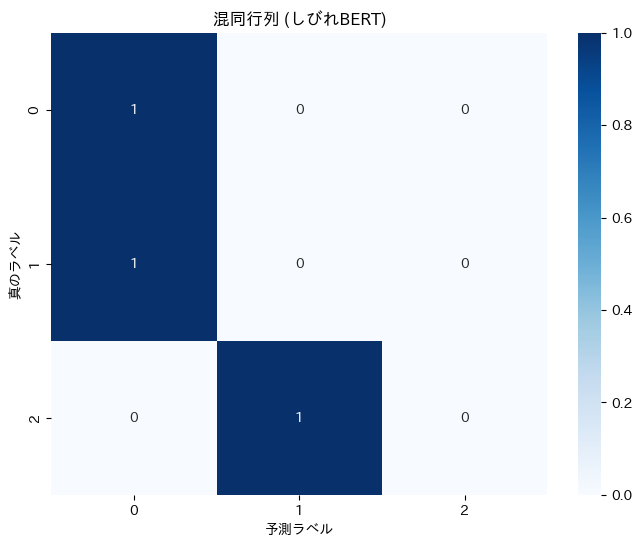

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
import japanize_matplotlib # Ensure Japanese font support

# 混同行列を計算
cm_shibire = confusion_matrix(true_labels_shibire, predictions_shibire)

# クラス名を取得（エンコード前のラベル）
class_names_shibire = label_encoder_shibire.classes_

# 混同行列を可視化
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_shibire,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names_shibire,
    yticklabels=class_names_shibire
)
plt.xlabel('予測ラベル')
plt.ylabel('真のラベル')
plt.title('混同行列 (しびれBERT)')
plt.show()

In [50]:
from IPython.display import display, HTML
import torch

# 1. モデルのAttention出力を有効化
model_shibire.config.output_attentions = True

# 2. 推論実行 (Using the same example text as before for consistency)
text_shibire = "どうしましたか。昼ごろから頭が痛いと言っていたんですが、さっき様子を見に行ったら、片側がしびれるみたいで、いつもと全然違うんです。頭痛は突然ひどくなったわけではないですか。はい、急にではないです。何時間か前から続いていて、だんだん悪くなったようです。しびれや麻痺はどこに出ていますか。右の手足がしびれると言っています。歩こうとしても片側に寄ってしまいます。いつもと違う受け答えや行動はありますか。あります。部屋の鍵をどこに置いたか急にわからなくなって、私の名前もすぐ出てきませんでした。" # You can change this input text
inputs_shibire = tokenizer_shibire(text_shibire, return_tensors='pt', add_special_tokens=True).to(device_shibire)

with torch.no_grad():
    outputs_shibire = model_shibire(**inputs_shibire)

# 3. 最後の層のAttentionを取得
# 形状: [num_heads, sequence_length, sequence_length]
attn_weights_shibire = outputs_shibire.attentions[-1][0]

# 全ヘッドの平均をとる
avg_attn_shibire = attn_weights_shibire.mean(dim=0)

# [CLS]トークン（文頭）が他のトークンに向けたAttentionを取得
# [CLS]のインデックス0の行を取り出します
cls_attention_shibire = avg_attn_shibire[0]

# 4. トークンの取得
tokens_shibire = tokenizer_shibire.convert_ids_to_tokens(inputs_shibire['input_ids'][0])

# 5. HTMLで可視化
html_output_shibire = ""
for token, weight in zip(tokens_shibire, cls_attention_shibire):
    # 重みを0~1に正規化（表示を見やすくするために係数をかけて調整）
    # 値が小さい場合は少し底上げして見えやすくします
    opacity = min(weight.item() * 10, 1.0)

    # 背景色（黄色）の不透明度(opacity)をAttentionスコアに連動させる
    html_output_shibire += f'<span style="background-color: rgba(255, 255, 0, {opacity}); padding: 2px; border-radius: 3px;">{token}</span> '

print("\n--- Attention Visualization (しびれBERT) ---")
display(HTML(html_output_shibire))


--- Attention Visualization (しびれBERT) ---


##3.3.ひし形_3専用BERT

###3.3.1.学習

In [ ]:
# !pip install transformers fugashi unidic-lite torch pandas japanize-matplotlib

###3.3.2.評価とAttention

##3.3.ひし形_3専用BERT

###3.3.1.学習

In [51]:
# !pip install transformers fugashi unidic-lite torch pandas japanize-matplotlib

In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import BertJapaneseTokenizer, BertForSequenceClassification
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Filter the DataFrame based on '採用ペア_ひし形_全通り_頭痛_3' being True
filtered_df_behavior = df[df['採用ペア_ひし形_全通り_頭痛_3'] == True]

# Group by 'id' and concatenate the 'ペア' column
processed_data_behavior = filtered_df_behavior.groupby('id').agg(
    input_text=('ペア', lambda x: ' '.join(x)),
    label=('振る舞い', 'first') # Target label for ひし形_3 is '振る舞い'
).reset_index()

# Encode the '振る舞い' column to numerical labels
label_encoder_behavior = LabelEncoder()
processed_data_behavior['encoded_label'] = label_encoder_behavior.fit_transform(processed_data_behavior['label'])

# Check unique labels for num_labels
unique_labels_behavior = processed_data_behavior['encoded_label'].nunique()
print(f"Number of unique '振る舞い' labels: {unique_labels_behavior}")
if unique_labels_behavior <= 1:
    print("Warning: Only one or no unique '振る舞い' label found. Multi-class classification cannot be performed.")
    print("Please adjust your data filtering or input CSV to include multiple '振る舞い' categories for multi-class classification.")

# Split the data into training and testing sets
X_behavior = processed_data_behavior['input_text']
y_behavior = processed_data_behavior['encoded_label']

# Use a consistent random state for reproducibility
X_train_behavior, X_test_behavior, y_train_behavior, y_test_behavior = train_test_split(
    X_behavior, y_behavior, test_size=1/3, random_state=42, stratify=y_behavior if unique_labels_behavior > 1 else None
)

print(f"Training set size for 振る舞い: {len(X_train_behavior)}")
print(f"Test set size for 振る舞い: {len(X_test_behavior)}")

# Map original labels to encoded labels
label_mapping_behavior = dict(zip(label_encoder_behavior.classes_, label_encoder_behavior.transform(label_encoder_behavior.classes_)))
print(f"Label mapping for 振る舞い: {label_mapping_behavior}")

# Load tokenizer
tokenizer_behavior = BertJapaneseTokenizer.from_pretrained('cl-tohoku/bert-base-japanese-whole-word-masking')

# Tokenize training data
encoded_train_data_behavior = tokenizer_behavior(
    X_train_behavior.tolist(),
    padding='max_length',
    truncation=True,
    max_length=max_len, # Reusing max_len from previous context
    return_tensors='pt'
)

# Create TensorDataset for training
train_dataset_behavior = TensorDataset(
    encoded_train_data_behavior['input_ids'],
    encoded_train_data_behavior['attention_mask'],
    torch.tensor(y_train_behavior.tolist())
)

# Tokenize test data
encoded_test_data_behavior = tokenizer_behavior(
    X_test_behavior.tolist(),
    padding='max_length',
    truncation=True,
    max_length=max_len, # Reusing max_len from previous context
    return_tensors='pt'
)

# Create TensorDataset for test
test_dataset_behavior = TensorDataset(
    encoded_test_data_behavior['input_ids'],
    encoded_test_data_behavior['attention_mask'],
    torch.tensor(y_test_behavior.tolist())
)

# Create DataLoaders
train_dataloader_behavior = DataLoader(train_dataset_behavior, batch_size=4, shuffle=True)
test_dataloader_behavior = DataLoader(test_dataset_behavior, batch_size=4, shuffle=False)

# Load model
device_behavior = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_behavior = BertForSequenceClassification.from_pretrained(
    'cl-tohoku/bert-base-japanese-whole-word-masking',
    num_labels=unique_labels_behavior,
    attn_implementation='eager'
)
model_behavior.to(device_behavior)
optimizer_behavior = AdamW(model_behavior.parameters(), lr=2e-5)

# Training loop
epochs = 3 # Reusing epochs from previous context
print("\n--- Training for 振る舞い BERT ---")
for epoch in range(epochs):
    train_loss = train_shibire(model_behavior, train_dataloader_behavior, optimizer_behavior, device_behavior)
    test_loss, accuracy, f1, precision, recall, _, _ = evaluate_shibire(model_behavior, test_dataloader_behavior, device_behavior, label_encoder_behavior)
    print(f"Epoch {epoch+1}: Train Loss {train_loss:.4f}, Test Loss {test_loss:.4f}, Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

Number of unique '振る舞い' labels: 3
Training set size for 振る舞い: 4
Test set size for 振る舞い: 3
Label mapping for 振る舞い: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cl-tohoku/bert-base-japanese-whole-word-masking
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the che


--- Training for 振る舞い BERT ---
Epoch 1: Train Loss 1.2070, Test Loss 1.1016, Accuracy: 0.0000, F1-Score: 0.0000, Precision: 0.0000, Recall: 0.0000
Epoch 2: Train Loss 1.1138, Test Loss 1.1096, Accuracy: 0.3333, F1-Score: 0.1667, Precision: 0.1111, Recall: 0.3333
Epoch 3: Train Loss 0.9741, Test Loss 1.1426, Accuracy: 0.3333, F1-Score: 0.1667, Precision: 0.1111, Recall: 0.3333


###3.3.2.評価とAttention

In [53]:
import numpy as np

model_behavior.eval()
predictions_behavior = []
true_labels_behavior = []

with torch.no_grad():
    for batch in test_dataloader_behavior:
        b_input_ids, b_input_mask, b_labels = [b.to(device_behavior) for b in batch]

        outputs = model_behavior(b_input_ids, attention_mask=b_input_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).flatten()

        predictions_behavior.extend(preds.cpu().numpy())
        true_labels_behavior.extend(b_labels.cpu().numpy())

# デコードされた予測ラベルと真のラベル
decoded_predictions_behavior = label_encoder_behavior.inverse_transform(predictions_behavior)
decoded_true_labels_behavior = label_encoder_behavior.inverse_transform(true_labels_behavior)

# テストデータと予測結果を結合して表示
results_df_behavior = pd.DataFrame({
    'Input Text': X_test_behavior.values,
    'True Label (Encoded)': y_test_behavior.values,
    'True Label': decoded_true_labels_behavior,
    'Predicted Label (Encoded)': predictions_behavior,
    'Predicted Label': decoded_predictions_behavior
})

print("\n--- テストデータに対する予測結果 (振る舞いBERT) ---")
display(results_df_behavior)


--- テストデータに対する予測結果 (振る舞いBERT) ---


,Input Text,True Label (Encoded),True Label,Predicted Label (Encoded),Predicted Label
0,その頭痛は急に起きたんですね。 はい、食べている途中で急でした。,0,0,0,0
1,救急ですか、火事ですか。 救急です。うちの従業員が頭痛で仕事を続けられなくなっています。,1,1,0,0
2,救急ですか、火事ですか。 救急です。近所の方が頭が痛いと言って、部屋の前でうずくまっています。,2,2,0,0


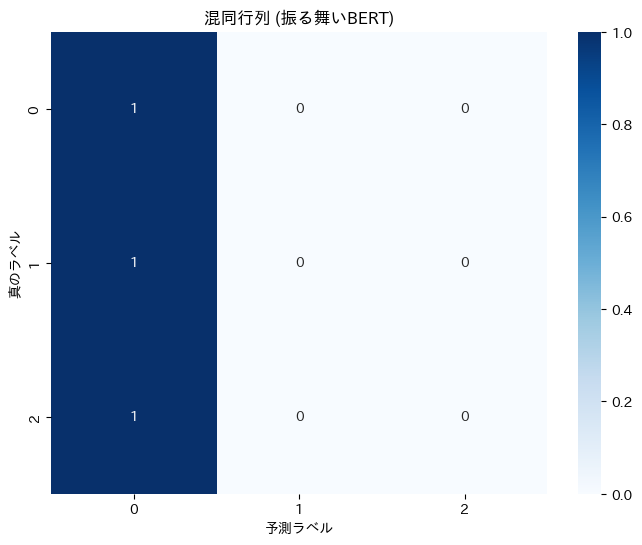

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
import japanize_matplotlib # Ensure Japanese font support

# 混同行列を計算
cm_behavior = confusion_matrix(true_labels_behavior, predictions_behavior)

# クラス名を取得（エンコード前のラベル）
class_names_behavior = label_encoder_behavior.classes_

# 混同行列を可視化
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_behavior,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names_behavior,
    yticklabels=class_names_behavior
)
plt.xlabel('予測ラベル')
plt.ylabel('真のラベル')
plt.title('混同行列 (振る舞いBERT)')
plt.show()

In [55]:
from IPython.display import display, HTML
import torch

# 1. モデルのAttention出力を有効化
model_behavior.config.output_attentions = True

# 2. 推論実行 (Using the same example text as before for consistency)
text_behavior = "どうしましたか。昼ごろから頭が痛いと言っていたんですが、さっき様子を見に行ったら、片側がしびれるみたいで、いつもと全然違うんです。頭痛は突然ひどくなったわけではないですか。はい、急にではないです。何時間か前から続いていて、だんだん悪くなったようです。しびれや麻痺はどこに出ていますか。右の手足がしびれると言っています。歩こうとしても片側に寄ってしまいます。いつもと違う受け答えや行動はありますか。あります。部屋の鍵をどこに置いたか急にわからなくなって、私の名前もすぐ出てきませんでした。" # You can change this input text
inputs_behavior = tokenizer_behavior(text_behavior, return_tensors='pt', add_special_tokens=True).to(device_behavior)

with torch.no_grad():
    outputs_behavior = model_behavior(**inputs_behavior)

# 3. 最後の層のAttentionを取得
# 形状: [num_heads, sequence_length, sequence_length]
attn_weights_behavior = outputs_behavior.attentions[-1][0]

# 全ヘッドの平均をとる
avg_attn_behavior = attn_weights_behavior.mean(dim=0)

# [CLS]トークン（文頭）が他のトークンに向けたAttentionを取得
# [CLS]のインデックス0の行を取り出します
cls_attention_behavior = avg_attn_behavior[0]

# 4. トークンの取得
tokens_behavior = tokenizer_behavior.convert_ids_to_tokens(inputs_behavior['input_ids'][0])

# 5. HTMLで可視化
html_output_behavior = ""
for token, weight in zip(tokens_behavior, cls_attention_behavior):
    # 重みを0~1に正規化（表示を見やすくするために係数をかけて調整）
    # 値が小さい場合は少し底上げして見えやすくします
    opacity = min(weight.item() * 10, 1.0)

    # 背景色（黄色）の不透明度(opacity)をAttentionスコアに連動させる
    html_output_behavior += f'<span style="background-color: rgba(255, 255, 0, {opacity}); padding: 2px; border-radius: 3px;">{token}</span> '

print("\n--- Attention Visualization (振る舞いBERT) ---")
display(HTML(html_output_behavior))


--- Attention Visualization (振る舞いBERT) ---
